<a href="https://colab.research.google.com/github/sandrotissi/book-recommender/blob/main/Book_Recommender_16.04_17h13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics.pairwise import cosine_similarity


#### Step 1: Load the Data

We’ll start by loading the datasets in the `data` folder. We have 3 datasets here:
- `interactions.csv`
- `movies.csv`
- `links.csv`


In [38]:
# Load the datasets
interactions = pd.read_csv('https://raw.githubusercontent.com/sandrotissi/book-recommender/0ca2f3f0ea5d72dd53b107ed15ea40401a48e74b/interactions_train.csv')
books = pd.read_csv("https://raw.githubusercontent.com/sandrotissi/book-recommender/0ca2f3f0ea5d72dd53b107ed15ea40401a48e74b/items.csv")
items = pd.read_csv("https://raw.githubusercontent.com/sandrotissi/book-recommender/0ca2f3f0ea5d72dd53b107ed15ea40401a48e74b/items.csv")
links = pd.read_csv("https://raw.githubusercontent.com/sandrotissi/book-recommender/0ca2f3f0ea5d72dd53b107ed15ea40401a48e74b/sample_submission.csv")
# Display the first rows of each dataset
display(interactions.head())
display(books.head())
display(links.head())


,u,i,t
0,4456,8581,1.687541e+09
1,142,1964,1.679585e+09
2,362,3705,1.706872e+09
3,1809,11317,1.673533e+09
4,4384,1323,1.681402e+09


,Title,Author,ISBN Valid,Publisher,Subjects,i
0,Classification décimale universelle : édition ...,NaN,9782871303336; 2871303339,Ed du CEFAL,Classification décimale universelle; Indexatio...,0
1,Les interactions dans l'enseignement des langu...,"Cicurel, Francine, 1947-",9782278058327; 2278058320,Didier,didactique--langue étrangère - enseignement; d...,1
2,Histoire de vie et recherche biographique : pe...,NaN,2343190194; 9782343190198,L'Harmattan,Histoires de vie en sociologie; Sciences socia...,2
3,Ce livre devrait me permettre de résoudre le c...,"Mazas, Sylvain, 1980-",9782365350020; 236535002X; 9782365350488; 2365...,Vraoum!,Moyen-Orient; Bandes dessinées autobiographiqu...,3
4,Les années glorieuses : roman /,"Lemaitre, Pierre, 1951-",9782702180815; 2702180817; 9782702183618; 2702...,Calmann-Lévy,France--1945-1975; Roman historique; Roman fra...,4


,user_id,recommendation
0,0,3758 11248 9088 9895 5101 6074 9295 14050 1096...
1,1,3263 726 1589 14911 6432 10897 6484 7961 8249 ...
2,2,13508 9848 12244 2742 11120 2893 2461 5439 116...
3,3,2821 10734 6357 5934 2085 12608 12539 10551 10...
4,4,12425 219 11602 1487 14178 489 13888 2110 4413...


# EDA

In [5]:
n_users = interactions.u.nunique()
n_items = interactions.i.nunique()
print(f'Number of users = {n_users}, \n Number of books = {n_items} \n Number of interactions = {len(interactions)}')


Number of users = 7838, 
 Number of books = 15109 
 Number of interactions = 87047


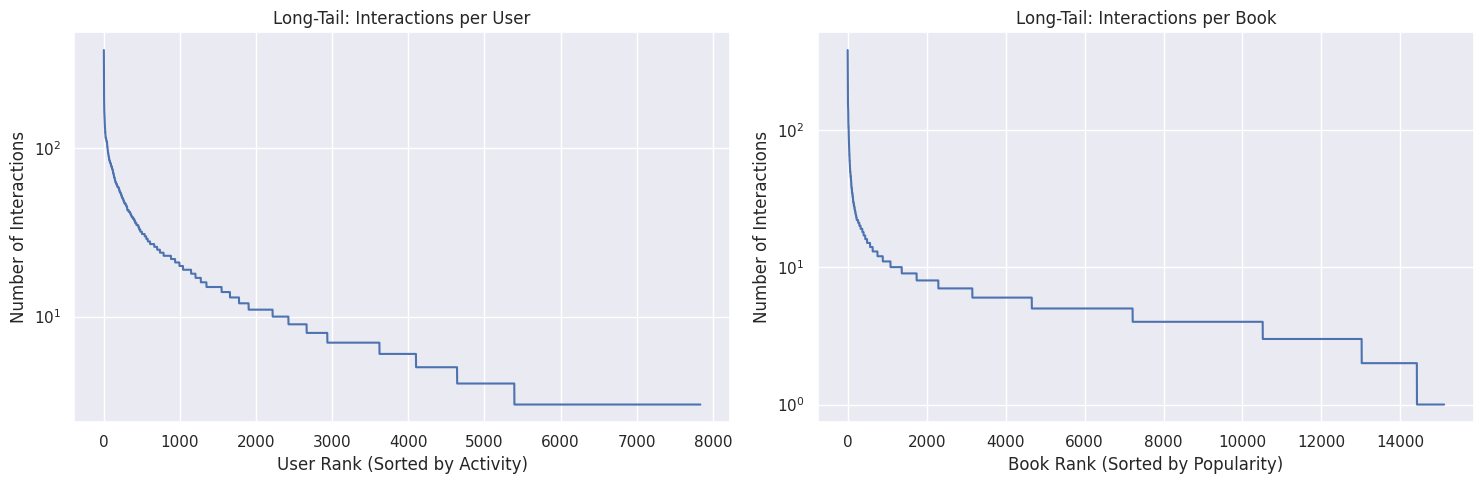

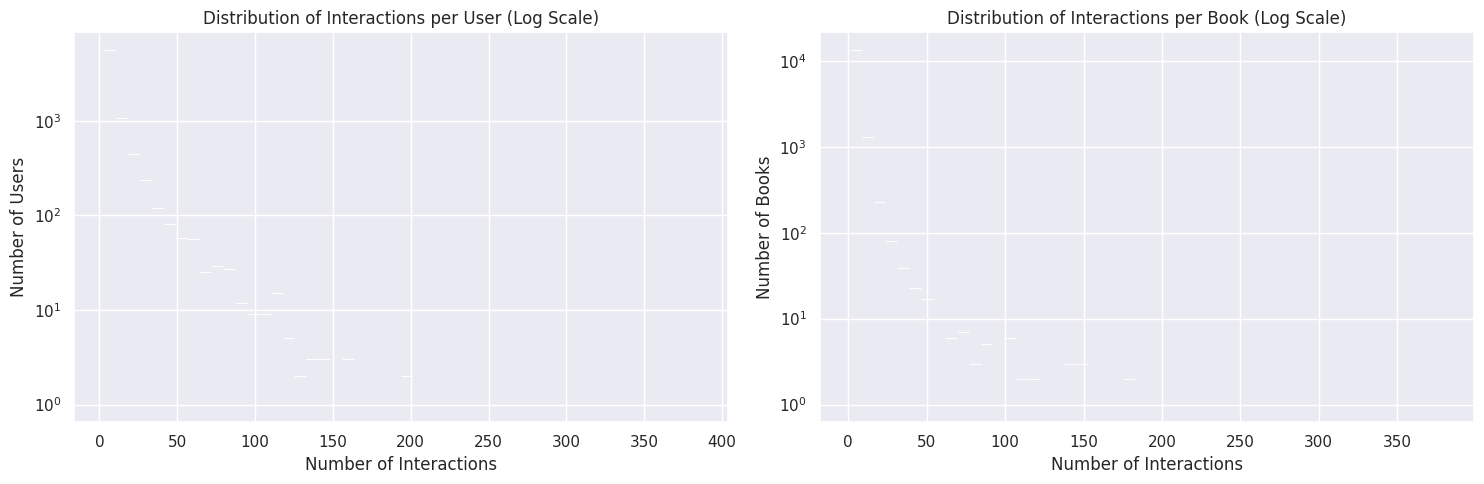

User Interaction Percentiles:
 count    7838.000000
mean       11.105767
std        16.441875
min         3.000000
25%         3.000000
50%         6.000000
75%        11.000000
90%        24.000000
99%        84.000000
max       385.000000
Name: count, dtype: float64

Item Interaction Percentiles:
 count    15109.000000
mean         5.761268
std          9.004874
min          1.000000
25%          3.000000
50%          4.000000
75%          6.000000
90%          9.000000
99%         29.000000
max        380.000000
Name: count, dtype: float64

Original interactions: 87047
Filtered interactions: 56051
Data retained: 64.39%


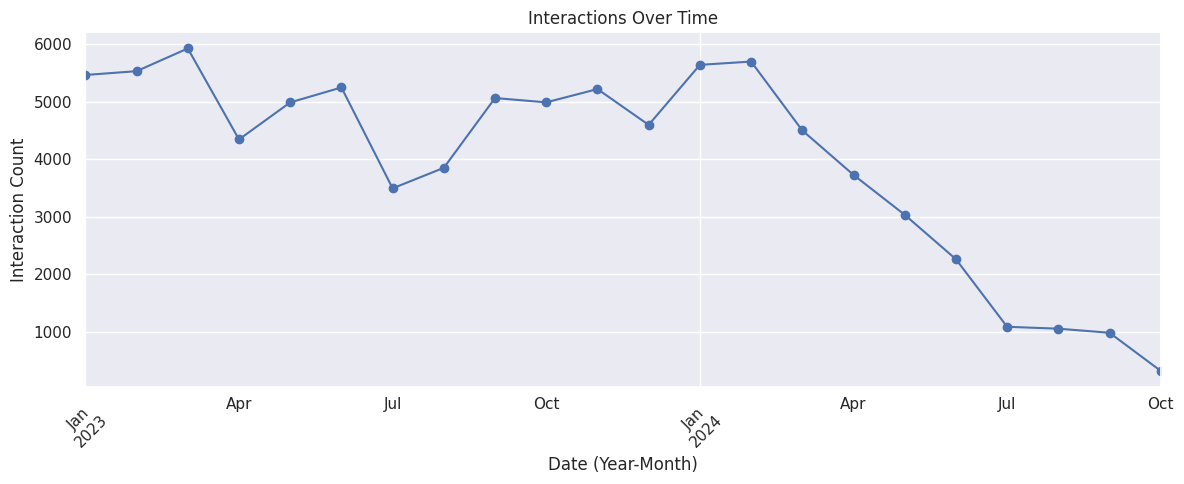

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_style("darkgrid")
# ==========================================
# 1. Analyze the Long-Tail Distribution
# ==========================================
# Better Alternative: Long-Tail Line Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sort the values in descending order
user_counts_sorted = user_counts.sort_values(ascending=False).values
item_counts_sorted = item_counts.sort_values(ascending=False).values

# Plot Users
axes[0].plot(user_counts_sorted)
axes[0].set_title('Long-Tail: Interactions per User')
axes[0].set_xlabel('User Rank (Sorted by Activity)')
axes[0].set_ylabel('Number of Interactions')
axes[0].set_yscale('log') # Optional: log scale for better visibility

# Plot Books
axes[1].plot(item_counts_sorted)
axes[1].set_title('Long-Tail: Interactions per Book')
axes[1].set_xlabel('Book Rank (Sorted by Popularity)')
axes[1].set_ylabel('Number of Interactions')
axes[1].set_yscale('log') # Optional

plt.tight_layout()
plt.show()

# Print basic percentiles to understand the skew
print("User Interaction Percentiles:\n", user_counts.describe(percentiles=[.25, .5, .75, .9, .99]))
print("\nItem Interaction Percentiles:\n", item_counts.describe(percentiles=[.25, .5, .75, .9, .99]))


# ==========================================
# 2. Filter the Thresholds (Example)
# ==========================================
# Define minimum interaction thresholds to remove noise
MIN_USER_INTERACTIONS = 5
MIN_ITEM_INTERACTIONS = 5

valid_users = user_counts[user_counts >= MIN_USER_INTERACTIONS].index
valid_items = item_counts[item_counts >= MIN_ITEM_INTERACTIONS].index

filtered_interactions = interactions[
    (interactions['u'].isin(valid_users)) &
    (interactions['i'].isin(valid_items))
]

print(f"\nOriginal interactions: {len(interactions)}")
print(f"Filtered interactions: {len(filtered_interactions)}")
print(f"Data retained: {(len(filtered_interactions) / len(interactions) * 100):.2f}%")


# ==========================================
# 3. Evaluate Temporal Dynamics
# ==========================================

# Convert Unix timestamp to datetime
interactions['datetime'] = pd.to_datetime(interactions['t'], unit='s')

# Create a Year-Month column for plotting
interactions['year_month'] = interactions['datetime'].dt.to_period('M')

# Plot interactions over time
monthly_interactions = interactions.groupby('year_month').size()

plt.figure(figsize=(12, 5))
monthly_interactions.plot(kind='line', marker='o')
plt.title('Interactions Over Time')
plt.xlabel('Date (Year-Month)')
plt.ylabel('Interaction Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




# Test 100% AI

In [41]:
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# 1. Map original IDs to sequential indices for the matrix
# (Assuming 'u' and 'i' are already numeric, but we ensure they map from 0 to N)
user_c = interactions['u'].astype('category')
item_c = interactions['i'].astype('category')

interactions['user_id_matrix'] = user_c.cat.codes
interactions['item_id_matrix'] = item_c.cat.codes

# Mappings to decode later
item_id_map = dict(enumerate(item_c.cat.categories))
reverse_item_map = {v: k for k, v in item_id_map.items()}

# 2. Build the Sparse Item-User Matrix
# Rows are Items, Columns are Users. Values are 1 (interacted)
sparse_item_user = csr_matrix(
    (np.ones(len(interactions)), (interactions['item_id_matrix'], interactions['user_id_matrix']))
)

# 3. Calculate Cosine Similarity between items
# Note: For 15k items, this creates a 15k x 15k dense matrix (~1.8 GB in memory)
item_similarities = cosine_similarity(sparse_item_user)

def get_collab_recommendations(target_item_id, top_n=5):
    """Returns top N similar items based on user interaction overlap."""
    if target_item_id not in reverse_item_map:
        return "Item not found in interaction data."

    idx = reverse_item_map[target_item_id]

    # Get similarity scores for this item, sort them descending
    sim_scores = list(enumerate(item_similarities[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top N (excluding the item itself at index 0)
    top_items_indices = [i[0] for i in sim_scores[1:top_n+1]]

    # Return original Item IDs
    recommended_ids = [item_id_map[i] for i in top_items_indices]

    # Fetch details from the items dataframe
    return items[items['i'].isin(recommended_ids)][['i', 'Title', 'Author']]

# Example usage (replace 1964 with an actual item ID 'i' from your data)
print(get_collab_recommendations(1964))


           i                                              Title  \
2127    2127  La Syrie au-delà de la guerre : histoire, pol...   
2132    2132                              California dreamin' /   
2140    2140                Ma vie est tout à fait fascinante /   
10837  10837  Celle qui fuit et celle qui reste : époque int...   
12359  12359                                   L'atelier noir /   

                    Author  
2127   Tannous, Manon-Nour  
2132      Bagieu, Pénélope  
2140      Bagieu, Pénélope  
10837      Ferrante, Elena  
12359        Ernaux, Annie  


TypeError: get_collab_recommendations() got an unexpected keyword argument 'num_recs'

In [44]:

import pandas as pd
import numpy as np

def get_user_recommendations(user_id, num_recs=10):
    """Generates recommendations for a user based on their interaction history."""

    # 1. Find all items this user has interacted with
    user_history = interactions[interactions['u'] == user_id]['i'].tolist()

    # If the user has no history, return an empty string (or you could return top popular items)
    if not user_history:
        return ""

    # Map original item IDs to matrix indices
    history_indices = [reverse_item_map[i] for i in user_history if i in reverse_item_map]

    # 2. Sum the similarity scores of all items based on the user's history
    # This gives a higher score to items that are similar to multiple books the user read
    summed_scores = np.sum(item_similarities[history_indices], axis=0)

    # Create a Series to easily sort the scores
    scores_series = pd.Series(summed_scores)

    # 3. Filter out books the user has already interacted with
    scores_series = scores_series.drop(history_indices, errors='ignore')

    # 4. Get the top N highest scoring item indices
    top_item_indices = scores_series.nlargest(num_recs).index.tolist()

    # Map matrix indices back to original Item IDs and convert to strings
    recommended_item_ids = [str(item_id_map[idx]) for idx in top_item_indices]

    # 5. Join them into a space-separated string
    return " ".join(recommended_item_ids)


# ==========================================
# Generate the Output DataFrame
# ==========================================

# Select the first 10 unique users from your dataset
target_users = interactions['u'].unique()[:10]

# Generate the recommendations
output_data = []
for user in target_users:
    # Get 10 recommendations per user (adjust num_recs if you need more/less per string)
    recs_string = get_user_recommendations(user, num_recs=10)
    output_data.append({'user_id': user, 'recommendation': recs_string})

# Create and display the final DataFrame
submission_df = pd.DataFrame(output_data)
print(submission_df)


   user_id                                     recommendation
0     4456  13804 13806 2197 9210 7053 9209 2904 14933 559...
1      142  5068 4483 6641 1579 598 8469 10301 9309 3704 9988
2      362    7411 795 2024 1203 3258 7413 464 7043 5724 8469
3     1809  7494 6345 8970 6355 13693 14882 14884 7378 120...
4     4384  3465 14123 1166 12511 2820 1535 14124 14122 12...
5     2369                       2 18 20 3 19 13072 6 7 17 24
6      259  14932 11627 3813 14845 8622 13739 14642 14643 ...
7     6239  11753 2820 12426 1323 1535 2742 404 12511 1152...
8     2744  12735 12725 7081 12732 12729 12727 12730 11816...
9     6597  12314 8096 8508 12697 1343 7753 12313 8276 112...


In [39]:
# ==========================================
# Generate the Output DataFrame
# ==========================================

# Select the first 10 unique users from your dataset
target_users = interactions['u'].unique()[:10]

# Generate the recommendations
output_data = []
for user in target_users:
    # Get 10 recommendations per user (adjust num_recs if you need more/less per string)
    recs_string = get_user_recommendations(user, num_recs=10)
    output_data.append({'user_id': user, 'recommendation': recs_string})

# Create and display the final DataFrame
submission_df = pd.DataFrame(output_data)
print(submission_df)

NameError: name 'get_user_recommendations' is not defined

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Clean and combine text features
# Replace NaNs with empty strings and semicolons with spaces
items['clean_author'] = items['Author'].fillna('').astype(str)
items['clean_subjects'] = items['Subjects'].fillna('').astype(str).str.replace(';', ' ')

# Create a master feature string for each book
items['content_features'] = items['clean_author'] + " " + items['clean_subjects']

# 2. Vectorize the text using TF-IDF
tfidf = TfidfVectorizer(stop_words='english') # Use 'french' if the dataset is primarily French
tfidf_matrix = tfidf.fit_transform(items['content_features'])

# 3. Calculate Cosine Similarity
content_similarities = cosine_similarity(tfidf_matrix)

# Create an index to quickly find the row of a specific item ID
item_indices = pd.Series(items.index, index=items['i']).drop_duplicates()

def get_content_recommendations(target_item_id, top_n=5):
    """Returns top N similar items based on Author and Subjects."""
    if target_item_id not in item_indices:
        return "Item metadata not found."

    idx = item_indices[target_item_id]

    # Get similarity scores, sort descending
    sim_scores = list(enumerate(content_similarities[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top N (excluding itself)
    top_indices = [i[0] for i in sim_scores[1:top_n+1]]

    # Return recommendations
    return items.iloc[top_indices][['i', 'Title', 'Author', 'Subjects']]

# Example usage
# print(get_content_recommendations(1964))

# AI 2.0

In [49]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# Define the splits (assuming 'interactions' dataframe already has 'pct_rank')
train_data = interactions[interactions["pct_rank"] < 0.8].copy()
test_data = interactions[interactions["pct_rank"] >= 0.8].copy()

# 1. Create stable mappings based on the ENTIRE dataset
# This ensures the matrix dimensions stay consistent even if some items are only in the test set
all_users = interactions['u'].unique()
all_items = interactions['i'].unique()

user_to_idx = {u: idx for idx, u in enumerate(all_users)}
item_to_idx = {i: idx for idx, i in enumerate(all_items)}
idx_to_item = {idx: i for i, idx in item_to_idx.items()}

# 2. Map the training data to matrix indices
train_u_idx = train_data['u'].map(user_to_idx)
train_i_idx = train_data['i'].map(item_to_idx)

# 3. Build the Sparse Matrix STRICTLY from train_data
# Shape is fixed to total known users/items
train_sparse_matrix = csr_matrix(
    (np.ones(len(train_data)), (train_i_idx, train_u_idx)),
    shape=(len(all_items), len(all_users))
)

# 4. Calculate similarities based only on training interactions
item_similarities_train = cosine_similarity(train_sparse_matrix)

In [50]:
def get_recommendations_for_eval(user_id, train_df, k=10):
    """Generates Top-K recommendations using only training history."""

    # 1. Get user's history from the training set
    user_train_history = train_df[train_df['u'] == user_id]['i'].tolist()

    if not user_train_history:
        return [] # Cold-start users get no collaborative recommendations

    # Map history to matrix indices
    history_indices = [item_to_idx[i] for i in user_train_history]

    # 2. Sum similarities across all books the user read in training
    summed_scores = np.sum(item_similarities_train[history_indices], axis=0)
    scores_series = pd.Series(summed_scores)

    # 3. Remove books the user ALREADY read in the training set
    scores_series = scores_series.drop(history_indices, errors='ignore')

    # 4. Get the indices of the Top K highest scores
    top_indices = scores_series.nlargest(k).index.tolist()

    # Return actual Item IDs
    return [idx_to_item[idx] for idx in top_indices]

In [51]:
# Group the test data to see what each user actually read next
test_user_interactions = test_data.groupby('u')['i'].apply(set).to_dict()

hits = 0
total_test_interactions = 0
users_evaluated = 0

# Set K (number of recommendations to generate per user)
K = 10

print(f"Evaluating Recommender System (Recall@{K})...")

for user_id, actual_future_items in test_user_interactions.items():

    # Generate recommendations using ONLY their train data
    recommended_items = get_recommendations_for_eval(user_id, train_data, k=K)

    if not recommended_items:
        continue # Skip users who had no train data (pure cold start)

    recommended_set = set(recommended_items)

    # Check how many of the recommended items were actually read in the test set
    true_positives = len(actual_future_items.intersection(recommended_set))

    hits += true_positives
    total_test_interactions += len(actual_future_items)
    users_evaluated += 1

# Calculate final metrics
if total_test_interactions > 0:
    recall_at_k = hits / total_test_interactions
    print(f"\nEvaluation Complete for {users_evaluated} users.")
    print(f"Total Test Interactions Predicted: {hits} out of {total_test_interactions}")
    print(f"Recall@{K}: {recall_at_k:.4f} ({(recall_at_k * 100):.2f}%)")
else:
    print("No valid test interactions to evaluate.")

Evaluating Recommender System (Recall@10)...

Evaluation Complete for 7838 users.
Total Test Interactions Predicted: 606 out of 19409
Recall@10: 0.0312 (3.12%)


# Recommender Systems

## Task 1: Exploring the MovieLens Dataset with Implicit Feedback




In this part, we’ll be using the [MovieLens dataset](https://grouplens.org/datasets/movielens/). ‌We will use the Movielens-small dataset that contains 100,000 interactions of users with different movies. An interaction of a user with a movie is when a user rates a movie with a value from 1 to 5. In this walkthrough we want to focus on **implicit feedback** recommendation scenario, i.e., we are interested in the items that each user liked, or interacted with. Therefore, we have provided you with a subset of interactions in the dataset that contains the ratings larger than or equal to 4.


#### Step 2: Check the Number of interactions, users and movies

Let’s check how many unique users and items we have in this dataset.

In [6]:
n_users = interactions.u.nunique()
n_items = interactions.i.nunique()
print(f'Number of users = {n_users}, \n Number of books = {n_items} \n Number of interactions = {len(interactions)}')


Number of users = 7838, 
 Number of books = 15109 
 Number of interactions = 87047



#### Step 3: Split the Data into Training and Test Sets

Splitting the data to training and test sets for recommendation systems is different from what you have seen in other classification/regression problems. In recommender systems, we want to make recommendations (predictions) for each user. Therefore, we need to make sure that we have training and test data for each user. In other words, we have to split the interactions of each user to training and test sets. For instance, if we want to do 80-20 splitting, we need to make sure that we have 80% of each user's interactions in the training set and the remaining 20% in the test set.

Moreover, to have a splitting that is more aligned with the reality, it is better to do the splitting based on the timestamp of the interactions (if the timestamp data is available). To do so, we have to sort the interactions of each user based on time, and pick the first 80% interactions in the training set and the last 20% interactions in the test set. This is more aligned with the reality as we always want to predict the future interactions of a user, that is, *the items that the user might like in the future*.

The figure below can help you understand better how this splitting is done.



<img src='https://raw.githubusercontent.com/michalis0/MGT-502-Data-Science-and-Machine-Learning/master/08_Recommenders/data/image/train-test-split-reco.png' width="700">

In [46]:
# let's first sort the interactions by user and time stamp
interactions = interactions.sort_values(["u", "t"])
interactions.head(10)

,u,i,t,user_id_matrix,item_id_matrix
21035,0,0,1.680191e+09,0,0
28842,0,1,1.680783e+09,0,1
3958,0,2,1.680801e+09,0,2
29592,0,3,1.683715e+09,0,3
6371,0,3,1.683715e+09,0,3
41220,0,4,1.686569e+09,0,4
12217,0,5,1.687014e+09,0,5
19703,0,6,1.687014e+09,0,6
64522,0,7,1.687014e+09,0,7
29380,0,8,1.687260e+09,0,8


Next we can use the percentage rank from pandas to get a proportional ranking of the timestamps for each user. Check the documentation on how to use the `rank` function with groupby in pandas (https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.rank.html#pandas.core.groupby.DataFrameGroupBy.rank).

In [47]:
interactions["pct_rank"] = interactions.groupby("u")["t"].rank(pct=True, method='dense')
interactions.reset_index(inplace=True, drop=True)
interactions.head(10)

,u,i,t,user_id_matrix,item_id_matrix,pct_rank
0,0,0,1.680191e+09,0,0,0.04
1,0,1,1.680783e+09,0,1,0.08
2,0,2,1.680801e+09,0,2,0.12
3,0,3,1.683715e+09,0,3,0.16
4,0,3,1.683715e+09,0,3,0.20
5,0,4,1.686569e+09,0,4,0.24
6,0,5,1.687014e+09,0,5,0.28
7,0,6,1.687014e+09,0,6,0.32
8,0,7,1.687014e+09,0,7,0.36
9,0,8,1.687260e+09,0,8,0.40


Now all that remains is to pick the first 80% of each user's interactions for the training set and the rest for the test set. We can do so using the `pct_rank` column.

In [48]:
train_data = interactions[interactions["pct_rank"] < 0.8]
test_data = interactions[interactions["pct_rank"] >= 0.8]

In [10]:
print("Training set size:", train_data.shape[0])
print("Testing set size:", test_data.shape[0])


Training set size: 65419
Testing set size: 21628


## Task 2: Creating User-Item Matrices for Implicit Feedback


In [11]:

print('number of users =', n_users, '| number of books =', n_items)


number of users = 7838 | number of books = 15109


#### Step 1: Define the Function to Create the Data Matrix

Next, we’ll define a function that creates the user-item data matrix. Each matrix cell will contain a 1 if there was an interaction and a 0 otherwise.


In [12]:
import numpy as np

# Define a function to create the data matrix
def create_data_matrix(data, n_users, n_items):
    """
    This function returns a numpy matrix with shape (n_users, n_items).
    Each entry is a binary value indicating positive interaction.
    """
    data_matrix = np.zeros((n_users, n_items))
    data_matrix[data["u"].values, data["i"].values] = 1
    return data_matrix


#### Step 2: Create the Training and Testing Matrices

Now we can use the function to create matrices for both the training and testing data. Each cell in the matrix will show a 1 if there was a positive interaction in the training or testing data, and a 0 otherwise.

In [13]:
# Create the training and testing matrices
current_n_users = interactions['u'].max() + 1
current_n_items = interactions['i'].max() + 1

train_data_matrix = create_data_matrix(train_data, current_n_users, current_n_items)
test_data_matrix = create_data_matrix(test_data, current_n_users, current_n_items)

# Display the matrices to understand their structure
print('train_data_matrix')
print(train_data_matrix)
print("number of non-zero values: ", np.sum(train_data_matrix))
print('test_data_matrix')
print(test_data_matrix)
print("number of non-zero values: ", np.sum(test_data_matrix))

train_data_matrix
[[1. 1. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
number of non-zero values:  49689.0
test_data_matrix
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
number of non-zero values:  19409.0


#### Step 3: Visualize the User-Item Interaction Matrices

To better understand the distribution of  interactions, we’ll use a **heatmap** to visualize a subset of each user-item matrix. In the heatmap:
- Rows represent users, and columns represent items.
- Each cell shows whether there’s a positive interaction (`1`) or no interaction (`0`).
- A color gradient makes it easy to spot clusters of interactions.

We’ll visualize only a small portion of the interaction matrices (e.g., 50x50) to keep the display manageable.

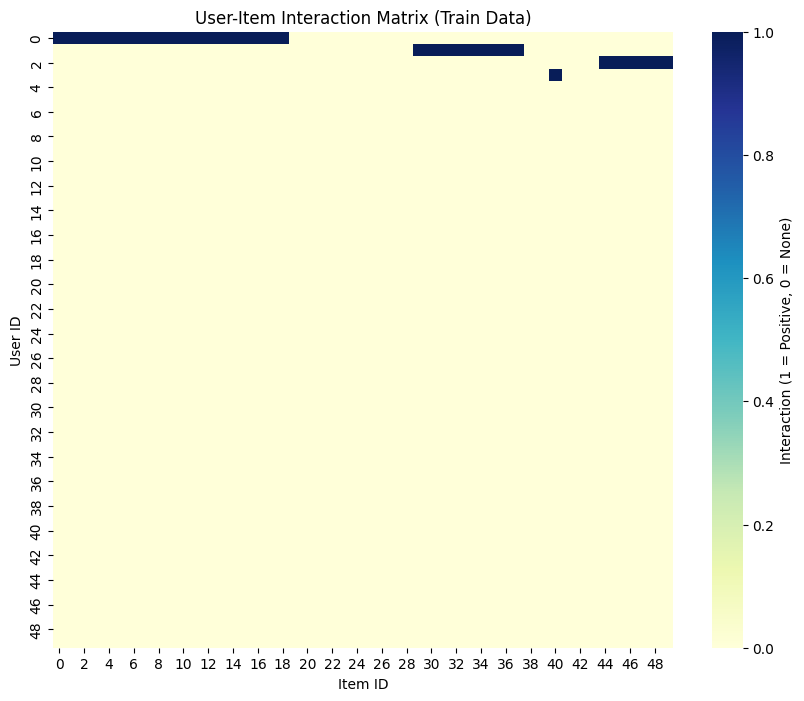

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot a heatmap for a subset of the user-item matrix
def plot_interaction_heatmap(data_matrix, title, num_users=50, num_items=50):
    """
    Plots a heatmap of a subset of the user-item interaction matrix.
    Parameters:
        data_matrix: The matrix to visualize.
        title: The title of the plot.
        num_users: The number of users to display (rows).
        num_items: The number of items to display (columns).
    """
    # Extract a subset of the matrix for visualization purposes
    matrix_subset = data_matrix[:num_users, :num_items]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="YlGnBu", cbar=True, cbar_kws={'label': 'Interaction (1 = Positive, 0 = None)'})
    plt.xlabel('Item ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the training and testing matrices
plot_interaction_heatmap(train_data_matrix, 'User-Item Interaction Matrix (Train Data)')



## Task 3: Item-to-Item Collaborative Filtering with Implicit Feedback

Now that we’ve prepared our data, our next task is to create a recommender system using **Item-to-Item Collaborative Filtering**. In this context, the recommendation translates to “Users who liked this item (movie) also liked …”.

Since we’re working with implicit feedback, the prediction formula will focus on the **likelihood of positive interactions** rather than ratings. This will predict items the user may interact with based on similarities to items they’ve previously liked.

The following formula shows how to compute the likelihood of interaction between a user $u$ and item $i$ using item-to-item collaborative filtering.

\begin{equation}
{p}_{u}(i) =  \frac{\sum\limits_{i' \in I} \text{sim}(i, i') \cdot {R}_{u}(i')}{\sum\limits_{i' \in I} \text{sim}(i, i')}
\end{equation}

In the above formula:


*   $p_u(i)$ is the likelihood of user $u$ interacting with item $i$. This is the value we want to compute.
*   $\text{sim}(i, i')$ is the cosine similarity between items $i$ and $i'$.
*   $R_u(i')$ is one if user $u$ has already interacted with item $i'$. Otherwise it is zero.
*   $I$ is the set of all items in the dataset.

The value $P_u(i)$ is expected to be between 0 and 1.



#### Step 1: Compute Item Similarity Matrix

As a first step, we’ll calculate the pairwise similarity matrix between all items using **cosine similarity**. This matrix will show how similar each item is to every other item based on the interaction patterns of users. The output will be an `n_items` by `n_items` symmetric 2D numpy matrix.

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute the item-item similarity matrix
# As the cosine_similarity function computes similarity between rows, we need to transpose
# the train_data_matrix to become items as rows and users as columns.
item_similarity = cosine_similarity(train_data_matrix.T)
print("Item-Item Similarity Matrix:")
print(item_similarity)
print(item_similarity.shape)


Item-Item Similarity Matrix:
[[1.         0.40824829 0.33333333 ... 0.         0.         0.        ]
 [0.40824829 1.         0.40824829 ... 0.         0.         0.        ]
 [0.33333333 0.40824829 1.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.         0.         0.         ... 0.         1.         0.        ]
 [0.         0.         0.         ... 0.         0.         1.        ]]
(15291, 15291)


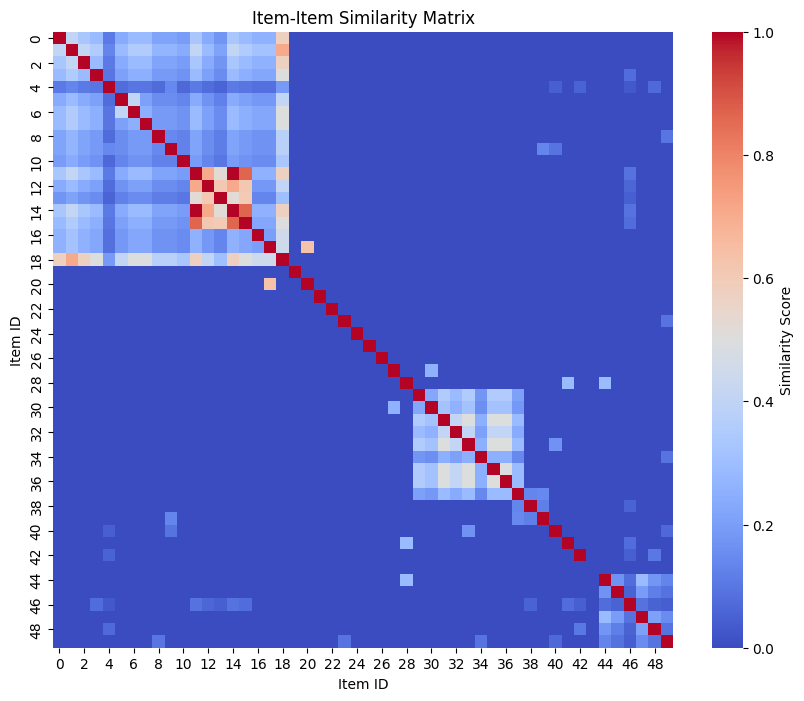

In [16]:
# Function to visualize the item similarity matrix
def plot_item_similarity_heatmap(similarity_matrix, title, num_items=50):
    """
    Plots a heatmap of a subset of the item similarity matrix.
    Parameters:
        similarity_matrix: The item-item similarity matrix.
        title: The title of the plot.
        num_items: The number of items to display (both rows and columns).
    """
    # Extract a subset of the matrix for visualization
    matrix_subset = similarity_matrix[:num_items, :num_items]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="coolwarm", cbar=True, cbar_kws={'label': 'Similarity Score'})
    plt.xlabel('Item ID')
    plt.ylabel('Item ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the item similarity matrix
plot_item_similarity_heatmap(item_similarity, 'Item-Item Similarity Matrix')


Let's have a look at the 2 items that have a similarity of one. Do you think they are actually similar? What do you think has happened here?

In [17]:
item_similarity[46, 37]

np.float64(0.0)

In [18]:
# Print the item with ID 11
display(books[books['i'] == 11])

# Print the item with ID 14
display(books[books['i'] == 14])

,Title,Author,ISBN Valid,Publisher,Subjects,i
11,Rendre les élèves acteurs de leurs apprentissa...,"Béal, Yves",9782206013725; 220601372X,Delagrave,apprentissage (psychologie)--enfant; apprentis...,11


,Title,Author,ISBN Valid,Publisher,Subjects,i
14,Une classe qui coopère : pourquoi ? comment ? /,"Staquet, Christian",9782850084324; 2850084328,Chronique sociale,apprentissage (psychologie)--classe (enseignem...,14


#### Step 2: Predict Positive Interactions Using Item Similarity

Next, we’ll use the item similarity matrix to predict the likelihood of positive interactions for each user with each item.

In what follows, we create a function that implements the above formula for item-to-item cf recommendation.

In [19]:
import numpy as np

# Define the function to predict interactions based on item similarity
def item_based_predict(interactions, similarity, epsilon=1e-9):
    """
    Predicts user-item interactions based on item-item similarity.
    Parameters:
        interactions (numpy array): The user-item interaction matrix.
        similarity (numpy array): The item-item similarity matrix.
        epsilon (float): Small constant added to the denominator to avoid division by zero.
    Returns:
        numpy array: The predicted interaction scores for each user-item pair.
    """
    # np.dot does the matrix multiplication. Here we are calculating the
    # weighted sum of interactions based on item similarity
    pred = similarity.dot(interactions.T) / (similarity.sum(axis=1)[:, np.newaxis] + epsilon)
    return pred.T  # Transpose to get users as rows and items as columns

# Calculate the item-based predictions for positive interactions
item_prediction = item_based_predict(train_data_matrix, item_similarity)
print("Predicted Interaction Matrix:")
print(item_prediction)
print(item_prediction.shape)

Predicted Interaction Matrix:
[[0.46097255 0.85435984 0.71867834 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
(7838, 15291)


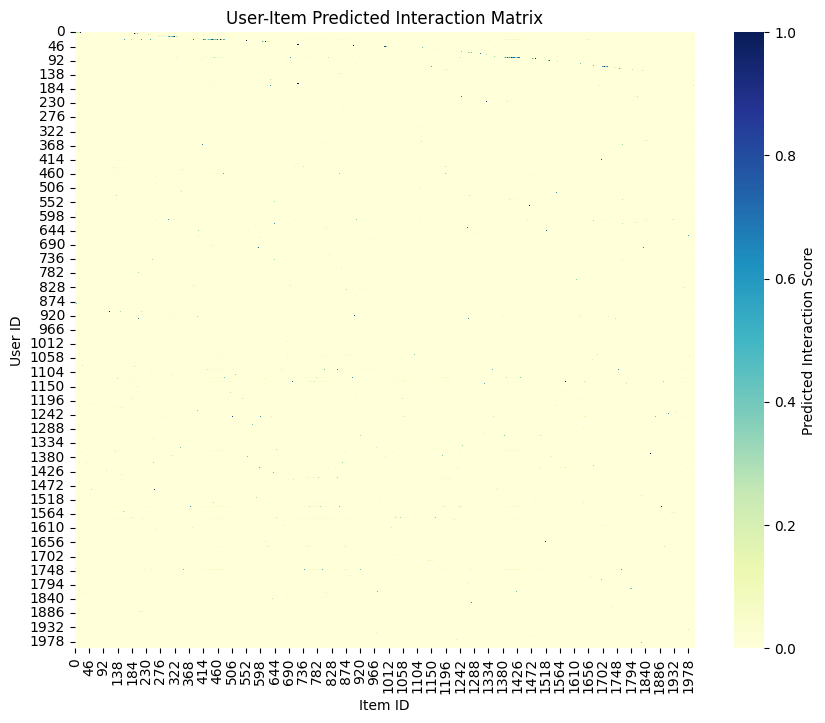

In [20]:
# Function to visualize the predicted interaction matrix for a subset of users and items
def plot_interaction_prediction_heatmap(prediction_matrix, title, num_users=2000, num_items=2000):
    """
    Plots a heatmap of a subset of the user-item predicted interaction matrix.
    Parameters:
        prediction_matrix: The predicted interaction matrix.
        title: The title of the plot.
        num_users: The number of users to display (rows).
        num_items: The number of items to display (columns).
    """
    # Extract a subset of the matrix for visualization
    matrix_subset = prediction_matrix[:num_users, :num_items]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="YlGnBu", cbar=True, cbar_kws={'label': 'Predicted Interaction Score'})
    plt.xlabel('Item ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the predicted interaction matrix
plot_interaction_prediction_heatmap(item_prediction, 'User-Item Predicted Interaction Matrix')



In this setup:
- The `item_based_predict` function calculates a score for each user-item pair using the item-to-item collaborative filtering formula.
- The result is a prediction matrix where each cell indicates the predicted likelihood of an interaction between each user and item.

## Task 4: User-to-User Collaborative Filtering with Implicit Feedback

In this task, we’ll create a recommender system using **User-to-User Collaborative Filtering**. This approach translates to “Users who are similar to you also liked…”. We’ll predict the likelihood of a user interacting with an item based on the behavior of similar users.


#### Step 1: Compute User Similarity Matrix

To start, we’ll compute the similarity matrix between users using **cosine similarity**. This matrix shows how similar each user is to every other user based on their interaction patterns. This will create an `n_users` by `n_users` matrix.

In [21]:
# Compute the user-user similarity matrix
user_similarity = cosine_similarity(train_data_matrix)
print("User-User Similarity Matrix:")
print(user_similarity)

# Check the shape as a sanity check
print("Shape of User Similarity Matrix:", user_similarity.shape)


User-User Similarity Matrix:
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
Shape of User Similarity Matrix: (7838, 7838)


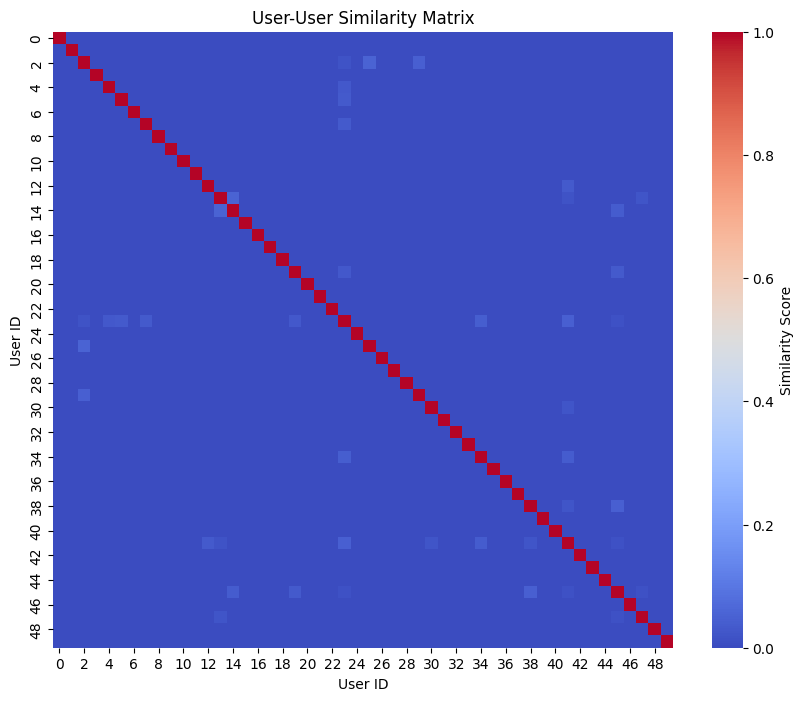

In [22]:
# Function to plot the user similarity matrix
def plot_user_similarity_heatmap(similarity_matrix, title, num_users=50):
    """
    Plots a heatmap of a subset of the user similarity matrix.
    Parameters:
        similarity_matrix: The user-user similarity matrix.
        title: The title of the plot.
        num_users: The number of users to display (both rows and columns).
    """
    # Extract a subset of the matrix for visualization
    matrix_subset = similarity_matrix[:num_users, :num_users]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="coolwarm", cbar=True, cbar_kws={'label': 'Similarity Score'})
    plt.xlabel('User ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the user similarity matrix
plot_user_similarity_heatmap(user_similarity, 'User-User Similarity Matrix')


### Step 2: Predict Positive Interactions Using User Similarity

Next, we’ll use the user similarity matrix to predict the likelihood of positive interactions for each user with each item. Since we’re working with implicit feedback, we’ll calculate a score for each item based on binary interaction values (1 for positive interactions, 0 for none).

The prediction formula is as follows:

\begin{equation}
{p}_{u}(i) = \frac{\sum\limits_{u' \in U} \text{sim}(u, u') \cdot {R}_{u'}(i)}{\sum\limits_{u' \in U} \text{sim}(u, u')}
\end{equation}


#### Explanation:
*   $p_u(i)$ is the likelihood of user $u$ interacting with item $i$. This is the value we want to compute.
*   $\text{sim}(u, u')$ is the cosine similarity between users $u$ and $u'$.
*   $R_u'(i)$ is one if user $u'$ has already interacted with item $i$. Otherwise it is zero.
*   $U$ is the set of all users in the dataset.


This formula calculates the likelihood of interaction between user $ u $ and item $ i $ based on interactions of similar users with that item. The weighted sum of interactions from similar users is normalized by the sum of the similarities.

- **`similarity.dot(interactions)`**: Calculates the weighted sum of interactions for each user, based on similar users’ interactions.
- **`np.abs(similarity).sum(axis=1)[:, np.newaxis]`**: The denominator normalizes the prediction by the sum of absolute similarities to avoid bias from users with more neighbors.
- **`epsilon`**: Prevents division by zero, which could result in `NaN` values.

In [23]:
# Define the function to predict interactions based on user similarity
def user_based_predict(interactions, similarity, epsilon=1e-9):
    """
    Predicts user-item interactions based on user-user similarity.
    Parameters:
        interactions (numpy array): The user-item interaction matrix.
        similarity (numpy array): The user-user similarity matrix.
        epsilon (float): Small constant added to the denominator to avoid division by zero.
    Returns:
        numpy array: The predicted interaction scores for each user-item pair.
    """
    # Calculate the weighted sum of interactions based on user similarity
    pred = similarity.dot(interactions) / (np.abs(similarity).sum(axis=1)[:, np.newaxis] + epsilon)
    return pred

# Calculate the user-based predictions for positive interactions
user_prediction = user_based_predict(train_data_matrix, user_similarity)
print("Predicted Interaction Matrix (User-Based):")
print(user_prediction)
print(user_prediction.shape)


Predicted Interaction Matrix (User-Based):
[[0.13171649 0.13259591 0.14274867 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
(7838, 15291)


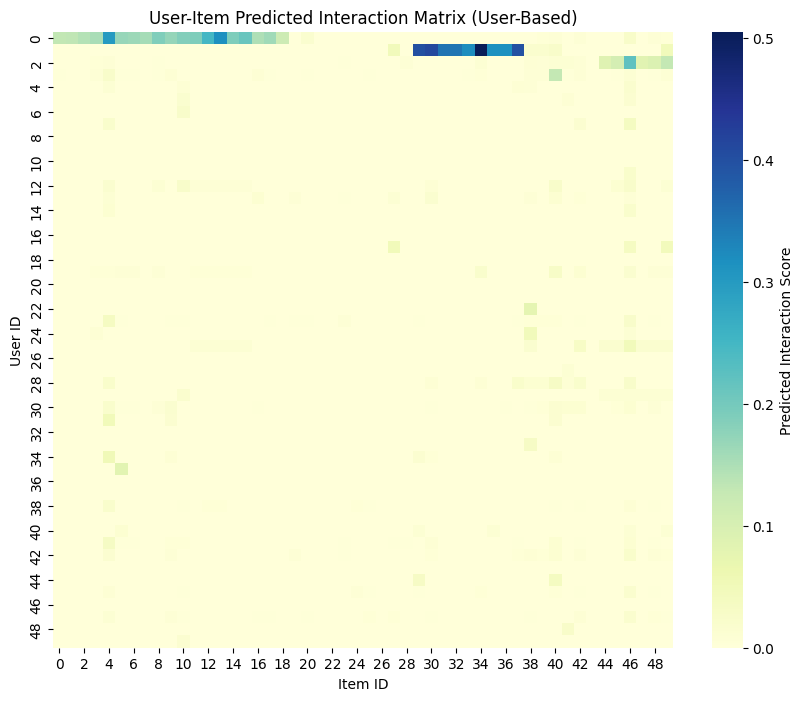

In [24]:
# Function to visualize the predicted interaction matrix for a subset of users and items
def plot_interaction_prediction_heatmap(prediction_matrix, title, num_users=50, num_items=50):
    """
    Plots a heatmap of a subset of the user-item predicted interaction matrix.
    Parameters:
        prediction_matrix: The predicted interaction matrix.
        title: The title of the plot.
        num_users: The number of users to display (rows).
        num_items: The number of items to display (columns).
    """
    # Extract a subset of the matrix for visualization
    matrix_subset = prediction_matrix[:num_users, :num_items]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="YlGnBu", cbar=True, cbar_kws={'label': 'Predicted Interaction Score'})
    plt.xlabel('Item ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the predicted interaction matrix
plot_interaction_prediction_heatmap(user_prediction, 'User-Item Predicted Interaction Matrix (User-Based)')


## Task 5: Evaluating Our Recommenders

#### Ranking Accuracy (Precision@K and Recall@K)

An implicit recommendation system is a ranking system that ranks items for each user based on their relevance to the user. Therefore, to evaluate such a system, we’re interested in the quality of the top-ranked recommendations rather than the actual predicted score for each recommendation. **Precision@K** and **Recall@K** focus on the top-K items recommended for each user, measuring the relevance of the top-ranked recommended items to the user.

- **Precision@K**: Measures the proportion of relevant items in the top-K recommendations.
  
  \begin{equation}
  \text{Precision@K} = \frac{\text{Number of relevant items in top-K}}{K}
  \end{equation}

- **Recall@K**: Measures the proportion of actual relevant items that appear in the top-K recommendations.

  \begin{equation}
  \text{Recall@K} = \frac{\text{Number of relevant items in top-K}}{\text{Total number of relevant items}}
  \end{equation}

Recall@K and Precision@K are metrics that are computed per user. To have a single value to evaluate a recommender system as a whole, we can take the average of Recall@K and Precision@K across all users.

### Your Turn !

As an exercise, complete the function precision_recall_at_k below to calculate Precision@K and Recall@K for a given value of K. Follow the instructions provided in the function to fill in the missing parts.

In [25]:
import numpy as np

# TODO: Implement the precision_recall_at_k function
def precision_recall_at_k(prediction, ground_truth, k=10):
    """
    Calculates Precision@K and Recall@K for top-K recommendations.
    Parameters:
        prediction (numpy array): The predicted interaction matrix with scores.
        ground_truth (numpy array): The ground truth interaction matrix (binary).
        k (int): Number of top recommendations to consider.
    Returns:
        precision_at_k (float): The average precision@K over all users.
        recall_at_k (float): The average recall@K over all users.
    """
    num_users = prediction.shape[0]
    precision_at_k, recall_at_k = 0, 0

    for user in range(num_users):
        # TODO: Get the indices of the top-K items for the user based on predicted scores
        top_k_items = np.argsort(prediction[user, :])[-k:]

        # TODO: Calculate the number of relevant items in the top-K items for the user
        relevant_items_in_top_k = np.isin(top_k_items, np.where(ground_truth[user, :] == 1)[0]).sum()

        # TODO: Calculate the total number of relevant items for the user
        total_relevant_items = ground_truth[user, :].sum()

        # Precision@K and Recall@K for this user
        precision_at_k += relevant_items_in_top_k / k
        recall_at_k += relevant_items_in_top_k / total_relevant_items if total_relevant_items > 0 else 0

    # Average Precision@K and Recall@K over all users
    precision_at_k /= num_users
    recall_at_k /= num_users

    return precision_at_k, recall_at_k


After completing the function, you can calculate Precision@K and Recall@K for the user-based and item-based predictions as follows:



In [26]:
# Run this line after implementing the function
precision_user_k, recall_user_k = precision_recall_at_k(user_prediction, test_data_matrix, k=10)
precision_item_k, recall_item_k = precision_recall_at_k(item_prediction, test_data_matrix, k=10)

print('User-based CF Precision@K:', precision_user_k)
print('User-based CF Recall@K:', recall_user_k)
print('Item-based CF Precision@K:', precision_item_k)
print('Item-based CF Recall@K:', recall_item_k)


User-based CF Precision@K: 0.0565577953559609
User-based CF Recall@K: 0.2906756989169525
Item-based CF Precision@K: 0.05567746874202883
Item-based CF Recall@K: 0.26399850355796506


## Task 6: Show the Recommendations for a Specific User

Pick a user at random. Extract the top-10 recommendations for this user by both the User-to-User and Item-to-Item Collaborative Filtering models. Present the recommendations by showing the movie posters.

__Hint:__ You can get the movie posters from the TMDb API. In the `links` DataFrame, you’ll find the TMDb ID corresponding to each movie. Using this ID, retrieve the movie poster and display it.

### Step 6.1: Select a User and Get Recommendations

Start by selecting a user at random, and then extract the top-10 recommended movies for that user from both the User-to-User and Item-to-Item models.

In [ ]:
import random
import numpy as np

# Pick a user at random
user_id = random.choice(range(user_prediction.shape[0]))
print("Selected User ID:", user_id)

# Get top-10 recommendations for the user from User-to-User CF
user_top_10 = np.argsort(user_prediction[user_id, :])[-10:][::-1]

# Get top-10 recommendations for the user from Item-to-Item CF
item_top_10 = np.argsort(item_prediction[user_id, :])[-10:][::-1]

# Display top-10 recommended movie IDs for both models
display(user_top_10)
display(item_top_10)

Selected User ID: 1380


array([ 2989, 10229, 13942,   372,  4310, 13995,  8544, 11206,  2636,
        7712])

array([10229, 14723,  2989,  7712, 13839, 14724, 13942, 11206,   372,
        8544])

### Step 6.2: Create Recommendation DataFrames with TMDb IDs

Merge the recommendations with the `links` and `movies` DataFrames to create two DataFrames (`user_recommendations_df` and `item_recommendations_df`) with columns `movie_id`, `title`, and `tmdbId`.

In [ ]:
import pandas as pd

# Convert user_top_10 and item_top_10 arrays into DataFrames
user_top_10_df = pd.DataFrame({'i': user_top_10})
item_top_10_df = pd.DataFrame({'i': item_top_10})

# Merge with links_df to get the tmdbId
user_recommendations_df = user_top_10_df.merge(links, left_on='movie_id', right_on='movie_id')
item_recommendations_df = item_top_10_df.merge(links, left_on='movie_id', right_on='movie_id')

# Merge with movies_df to add the title column
user_recommendations_df = user_recommendations_df.merge(movies[['movie_id', 'title']], left_on='movie_id', right_on='movie_id')
item_recommendations_df = item_recommendations_df.merge(movies[['movie_id', 'title']], left_on='movie_id', right_on='movie_id')

# Select only the columns we want to display
user_recommendations_df = user_recommendations_df[['movie_id', 'title', 'tmdbId']]
item_recommendations_df = item_recommendations_df[['movie_id', 'title', 'tmdbId']]

# Display the results
display(user_recommendations_df)
display(item_recommendations_df)


KeyError: 'movie_id'

### Fetching and Displaying Movie Posters

The following code uses the **TMDb API** to fetch movie posters based on the `tmdbId` of each recommended movie. The `fetch_poster` function retrieves the movie poster URL, and the `show_recommendations` function displays the posters for the top-10 recommendations.

You’ll use these functions in the next step to display the movie recommendations for a specific user.

In [ ]:
%pip install tmdbv3api

In [ ]:
from tmdbv3api import TMDb, Movie
import pandas as pd

# Set up the TMDb API with your API key
tmdb = TMDb()
tmdb.api_key = '37117cc09d5e00673f14f1cb7c7468b2'  # Replace with your actual TMDb API key

movie_api = Movie()

# Function to fetch movie posters
def fetch_poster(tmdb_id):
    try:
        details = movie_api.details(tmdb_id)
        poster_path = details.poster_path
        return f"https://image.tmdb.org/t/p/w200{poster_path}" if poster_path else None
    except:
        return None

#### Displaying Movie Posters for Top-10 Recommendations

In this step, you’ll complete the `show_recommendations` function to display the movie posters for the top-10 recommendations for a specific user, using the `tmdbId` from the `links` DataFrame.

1. **Fetch the `tmdbId`** for each movie in the recommendations:
   - Use the `links` DataFrame to retrieve the `tmdbId` for each recommended `movie_id`.
   - This `tmdbId` is then used to fetch the poster image via the TMDb API.

2. **Fetch and Display the Poster Image**:
   - Use the `fetch_poster` function (already defined) to get the poster URL based on the `tmdbId`.
   - If the poster URL is available, retrieve the image using the `requests` library and display it in the subplot.
   - If no poster is available, show a "No Image" placeholder text.

Here’s the code with placeholders where you need to complete each step:

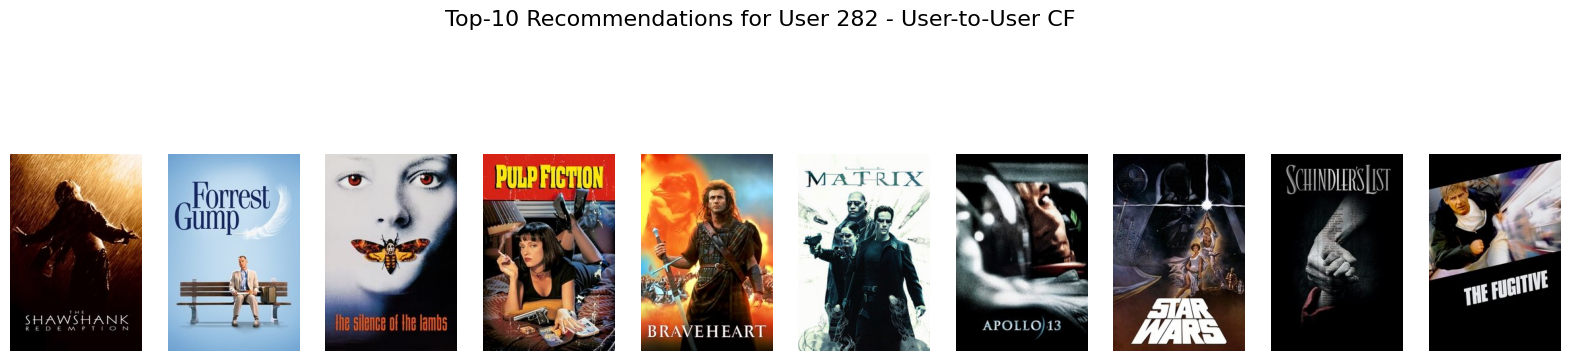

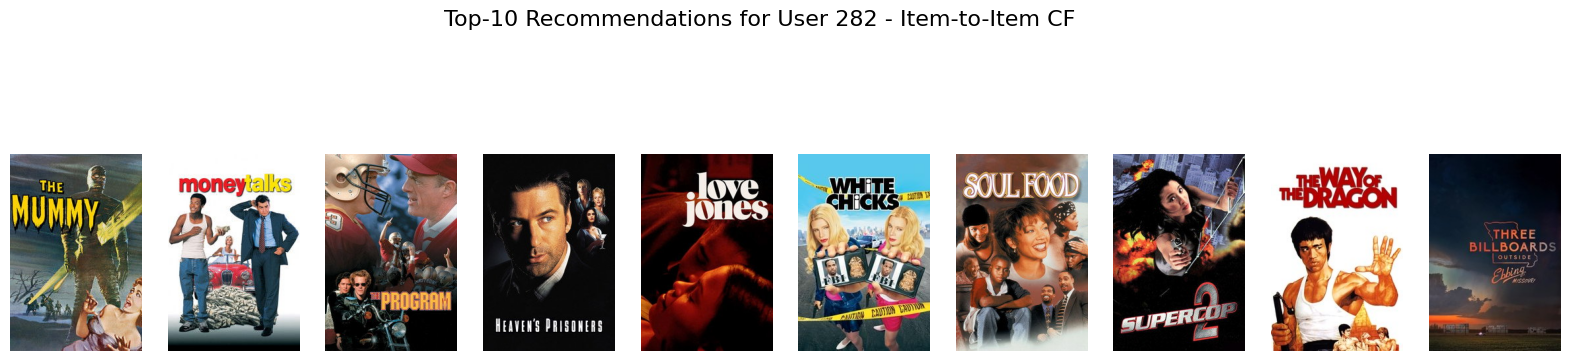

In [ ]:
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

def show_recommendations(recommendations, model_name):
    """
    Displays the movie posters for the top-10 recommended movies.

    Parameters:
    - recommendations: List or array of recommended movie IDs.
    - model_name: Name of the recommendation model (e.g., "User-to-User CF" or "Item-to-Item CF").
    """
    fig, axes = plt.subplots(1, len(recommendations), figsize=(20, 5))
    fig.suptitle(f"Top-10 Recommendations for User {user_id} - {model_name}", fontsize=16)

    for i, movie_id in enumerate(recommendations):
        # Step 1: Fetch the `tmdbId` for the movie from the `links` DataFrame
        # - Use `movie_id` to locate the corresponding `tmdbId`
        # - Ensure `tmdb_id` is extracted as an integer
        tmdb_id = links.loc[links['movie_id'] == movie_id, 'tmdbId'].values
        if len(tmdb_id) == 0:
            axes[i].axis('off')
            continue

        # Step 2: Fetch the poster URL using the `fetch_poster` function
        # - Pass `tmdb_id[0]` to `fetch_poster` and store the result in `poster_url`
        poster_url = fetch_poster(int(tmdb_id[0]))

        # Step 3: Display the poster image if available
        # - If `poster_url` is valid, use `requests` to get the image and display it
        # - If `poster_url` is None, display "No Image" text in the placeholder
        if poster_url:
            response = requests.get(poster_url)
            img = Image.open(BytesIO(response.content))
            axes[i].imshow(img)
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, "No Image", ha='center', va='center')
            axes[i].axis('off')

    plt.show()

# Example usage after completing the TODOs:
# Display top-10 recommendations for User-to-User CF
show_recommendations(user_top_10, "User-to-User CF")

# Display top-10 recommendations for Item-to-Item CF
show_recommendations(item_top_10, "Item-to-Item CF")